In [ ]:
import pandas as pd

df = pd.read_csv('NetFlix.csv')

# Menghitung persentase data kosong per kolom
persentase_kosong = (df.isnull().sum() / len(df)) * 100

# Menampilkan kolom yang ada data kosongnya saja, diurutkan dari yang terbesar
print("--- Persentase Data Kosong ---")
print(persentase_kosong[persentase_kosong > 0].sort_values(ascending=False))

--- Persentase Data Kosong ---
director      30.679337
cast           9.220496
country        6.510851
date_added     0.128419
rating         0.089893
dtype: float64


In [ ]:
import pandas as pd

# 1. Load Data
df = pd.read_csv('NetFlix.csv')

# --- TULIS KODE DATA CLEANING ANDA DI BAWAH INI ---
# 2. Isi 'Unknown' ke director, cast, country
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# 3. Hapus baris yang date_added atau rating-nya kosong
df = df.dropna(subset=['date_added', 'rating'])
# 4. Ubah date_added jadi tipe data datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# --- CEK HASILNYA ---
print(df.isnull().sum()) # Seharusnya sekarang semuanya 0!

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64


C:\Users\Advan\AppData\Local\Temp\ipykernel_1192\2253043697.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'])


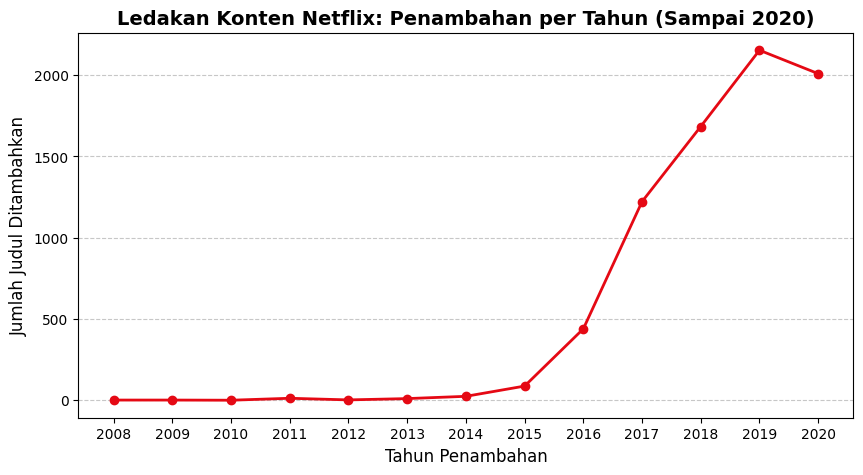

In [ ]:
import matplotlib.pyplot as plt

# 1. Ekstraksi Tahun
# Kita ambil tahunnya saja dari kolom date_added yang sudah berformat datetime
df['tahun_masuk'] = df['date_added'].dt.year

# 2. Agregasi Data
# Menghitung ada berapa baris (konten) yang masuk di setiap tahunnya, lalu urutkan sesuai tahun
tren_tahunan = df['tahun_masuk'].value_counts().sort_index()

# Catatan: Kita filter data hanya sampai tahun 2020. 
# (Tahun 2021 di dataset ini biasanya baru berjalan sebulan, jadi grafiknya akan terlihat menukik tajam secara tidak wajar jika dimasukkan)
tren_tahunan = tren_tahunan[tren_tahunan.index <= 2020]

# 3. Membuat Visualisasi
plt.figure(figsize=(10, 5)) # Ukuran kanvas
plt.plot(tren_tahunan.index, tren_tahunan.values, marker='o', color='#E50914', linewidth=2) # Merah khas Netflix

# 4. Mempercantik Grafik (Sangat penting untuk presentasi)
plt.title('Ledakan Konten Netflix: Penambahan per Tahun (Sampai 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun Penambahan', fontsize=12)
plt.ylabel('Jumlah Judul Ditambahkan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(tren_tahunan.index) # Memaksa semua angka tahun muncul di sumbu X

# Tampilkan grafik
plt.show()

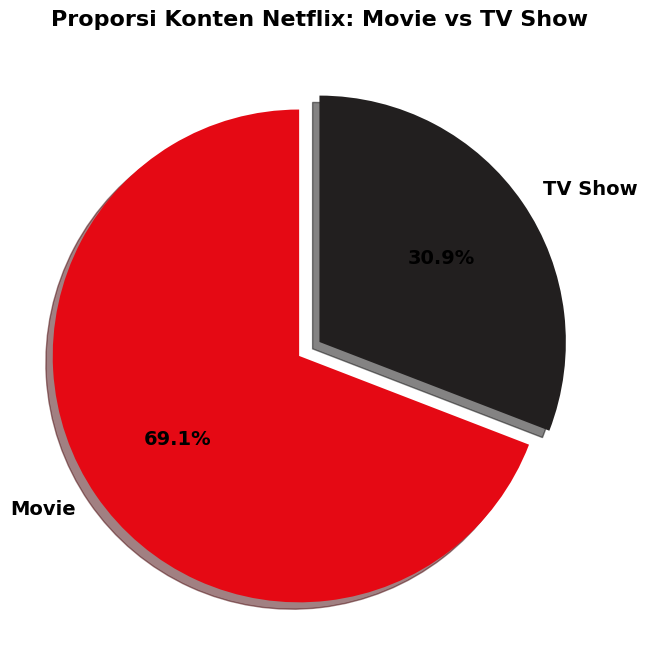

In [ ]:
import matplotlib.pyplot as plt

# 1. Menghitung jumlah masing-class tipe konten
komposisi_tipe = df['type'].value_counts()

# 2. Menyiapkan palet warna (Merah Netflix dan Hitam/Abu-abu gelap)
warna = ['#E50914', '#221F1F'] 

# 3. Membuat efek 'ledakan' (explode) agar potongan Movie sedikit menonjol keluar
ledakan = (0.1, 0) 

# 4. Membuat Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(komposisi_tipe, 
        labels=komposisi_tipe.index, 
        colors=warna, 
        explode=ledakan, 
        autopct='%1.1f%%', # Menampilkan persentase dengan 1 angka di belakang koma
        startangle=90,     # Memutar grafik agar tampilannya lebih seimbang
        shadow=True,       # Memberikan efek bayangan 3D
        textprops={'fontsize': 14, 'color': 'black', 'fontweight': 'bold'})

# 5. Menambahkan Judul
plt.title('Proporsi Konten Netflix: Movie vs TV Show', fontsize=16, fontweight='bold')

# Tampilkan grafik
plt.show()

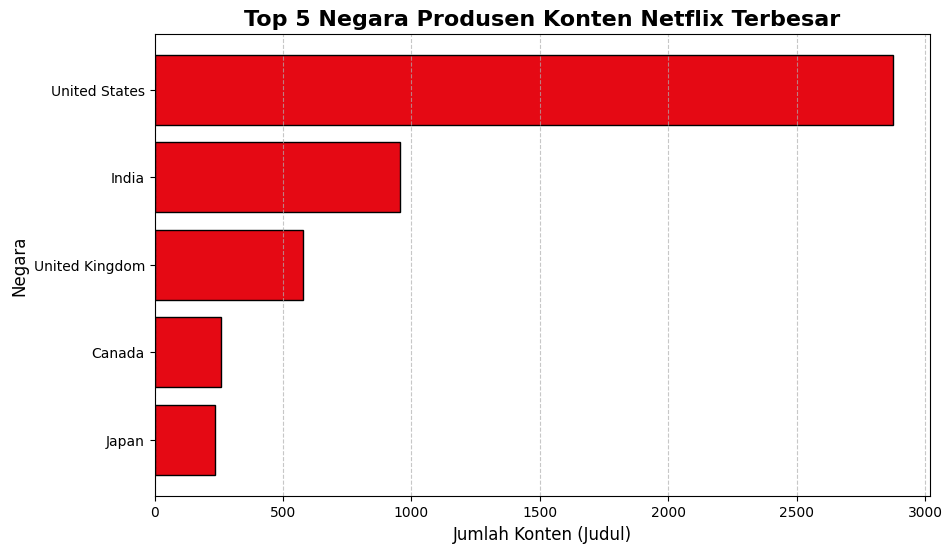

In [ ]:
import matplotlib.pyplot as plt

# 1. Feature Engineering: Ekstraksi Negara Utama
# Ambil data yang bukan 'Unknown'
df_negara = df[df['country'] != 'Unknown'].copy()

# Pecah teks berdasarkan koma, dan ambil elemen pertama (index 0)
df_negara['primary_country'] = df_negara['country'].apply(lambda x: x.split(',')[0])

# 2. Agregasi Data
# Hitung jumlah kemunculan tiap negara, ambil 5 teratas
top_5_negara = df_negara['primary_country'].value_counts().head(5)

# 3. Membuat Visualisasi (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))

# Kita balik urutannya ([::-1]) agar bar terpanjang berada di posisi paling atas grafik
plt.barh(top_5_negara.index[::-1], top_5_negara.values[::-1], color='#E50914', edgecolor='black')

# 4. Mempercantik Grafik
plt.title('Top 5 Negara Produsen Konten Netflix Terbesar', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Konten (Judul)', fontsize=12)
plt.ylabel('Negara', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tampilkan grafik
plt.show()

In [ ]:
import pandas as pd

# Asumsi Anda sudah menjalankan: df = pd.read_csv('NetFlix.csv')

# --- LANGKAH 1: MENDEFINISIKAN SYARAT (KATA KUNCI) ---
# Syarat 1: Genre harus mengandung kata 'Horror'
# (Kita pakai na=False agar Pandas tidak error jika tidak sengaja menemukan genre yang kosong)
syarat_genre = df['genres'].str.contains('Horror', na=False)

# Syarat 2: Tahun rilis harus 2019 ke atas (2019, 2020, 2021)
syarat_tahun = df['release_year'] >= 2019

# --- LANGKAH 2: MENERAPKAN FILTER ---
# Kita gabungkan kedua syarat tadi menggunakan simbol & (DAN)
df_tersaring = df[syarat_genre & syarat_tahun]

# --- LANGKAH 3: MEMILIH KOLOM & MENGURUTKAN HASIL ---
# Sama seperti trik Method Chaining yang Anda lakukan di latihan Python sebelumnya!
hasil_pencarian = (
    df_tersaring[['title', 'release_year', 'genres']]       # Pilih 3 kolom saja
    .sort_values(by='release_year', ascending=False)        # Urutkan dari tahun terbaru (descending)
    .head(5)                                                # Ambil 5 teratas
)

# Tampilkan hasil rekomendasi
print("=== 🍿 REKOMENDASI FILM HOROR TERBARU 🍿 ===")
print(hasil_pencarian.to_string(index=False)) # index=False agar nomor urut bawaan Pandas disembunyikan

=== 🍿 REKOMENDASI FILM HOROR TERBARU 🍿 ===
                         title  release_year                                       genres
                       Bulbbul          2020          Horror Movies, International Movies
                       Cadaver          2020          Horror Movies, International Movies
                   Castlevania          2020        Anime Series, TV Horror, TV Thrillers
Chilling Adventures of Sabrina          2020 TV Horror, TV Mysteries, TV Sci-Fi & Fantasy
                         Curon          2020 International TV Shows, TV Dramas, TV Horror
